# Backtest Results — Exploratory Analysis

This notebook analyzes the results of every backtest, optimization, and walk-forward run, read straight from the project's **SQLite results database** (`backtester.db`) with SQL. The schema is a normalized star around a `runs` table:

| table | grain | holds |
|---|---|---|
| `runs` | one execution | config + metadata |
| `metrics` | one per run | Sharpe, Sortino, win rate, drawdown, … |
| `trades` | one round-trip | symbol, side, pnl, hold time, exit reason |
| `equity_points` | one timestamp | mark-to-market equity |
| `wf_windows` | one walk-forward window | in-sample vs out-of-sample |

**Questions:** Which strategy actually has an edge? Where does the P&L come from? And does the edge survive out-of-sample, or is it overfit?

In [1]:
import os, sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams['figure.figsize'] = (9, 4)

# Resolve backtester.db whether run from repo root or the analysis/ folder.
_cands = ['backtester.db', os.path.join('..', 'backtester.db'),
          os.path.join(os.path.dirname(os.getcwd()), 'backtester.db')]
DB = os.environ.get('BACKTESTER_DB_PATH', next((p for p in _cands if os.path.exists(p)), _cands[0]))
con = sqlite3.connect(DB)

def q(sql):
    """Run SQL against the results DB and return a DataFrame."""
    return pd.read_sql_query(sql, con)

print('Connected to', DB)

Connected to ../backtester.db


## 1. What's in the database?
Orient first: how many runs of each type, across which strategies and data sources.

In [2]:
q('''
  SELECT run_type, strategy, data_source, COUNT(*) AS runs
  FROM runs
  GROUP BY run_type, strategy, data_source
  ORDER BY run_type, runs DESC
''')

,run_type,strategy,data_source,runs
0,backtest,fvg,ccxt,3
1,backtest,ema_pullback,ccxt,1
2,walkforward,fvg,ccxt,1


## 2. Strategy scorecard
Join each run to its headline `metrics` and compare strategies on risk-adjusted return, hit rate, and drawdown. Crucially, this groups by **strategy *and* timeframe** — the same strategy can behave completely differently across timeframes, so averaging them together would hide the effect (and let one bad regime drag down an otherwise fine strategy). Each row is one strategy/timeframe combination.

In [3]:
scorecard = q('''
  SELECT r.strategy,
         r.interval                        AS timeframe,
         COUNT(*)                          AS runs,
         ROUND(AVG(m.sharpe_ratio), 2)     AS avg_sharpe,
         ROUND(AVG(m.sortino_ratio), 2)    AS avg_sortino,
         ROUND(AVG(m.win_rate), 3)         AS avg_win_rate,
         ROUND(AVG(m.profit_factor), 2)    AS avg_profit_factor,
         ROUND(AVG(m.max_drawdown_pct), 3) AS avg_max_drawdown
  FROM runs r
  JOIN metrics m ON m.run_id = r.id
  WHERE r.run_type = 'backtest'
  GROUP BY r.strategy, r.interval
  ORDER BY avg_sharpe DESC
''')
scorecard

,strategy,timeframe,runs,avg_sharpe,avg_sortino,avg_win_rate,avg_profit_factor,avg_max_drawdown
0,ema_pullback,1h,1,1.760,2.710,0.576,1.470,-0.195
1,fvg,1h,2,0.210,0.300,0.629,1.000,-0.636
2,fvg,4h,1,-3.290,-4.350,0.563,0.490,-0.991


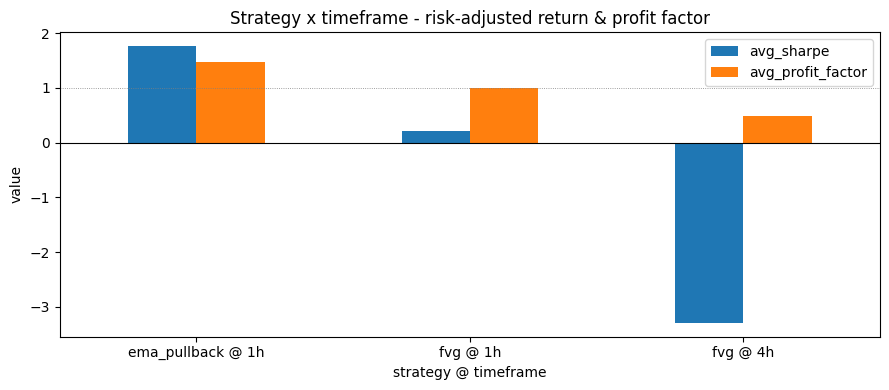

In [4]:
labels = scorecard['strategy'] + ' @ ' + scorecard['timeframe']
ax = scorecard.assign(config=labels).set_index('config')[
    ['avg_sharpe', 'avg_profit_factor']].plot.bar(rot=0)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(1, color='gray', lw=0.6, ls=':')  # profit factor break-even
ax.set_title('Strategy x timeframe - risk-adjusted return & profit factor')
ax.set_xlabel('strategy @ timeframe'); ax.set_ylabel('value')
plt.tight_layout(); plt.show()

## 3. Where does the P&L come from? Exit-reason economics
Every trade closes for a reason — a stop, a take-profit leg (`tp`, `tp1`, `tp2`), a trailing stop, or a timeout. Decomposing P&L by exit reason shows the strategy's true shape.

In [5]:
exits = q('''
  SELECT exit_reason,
         COUNT(*) AS trades,
         ROUND(100.0 * SUM(CASE WHEN pnl > 0 THEN 1 ELSE 0 END)/COUNT(*), 1) AS win_pct,
         ROUND(AVG(pnl_pct) * 100, 3) AS avg_return_pct,
         ROUND(SUM(pnl), 0)           AS total_pnl
  FROM trades
  GROUP BY exit_reason
  ORDER BY total_pnl DESC
''')
exits

,exit_reason,trades,win_pct,avg_return_pct,total_pnl
0,tp1,3602,99.600,2.458,"29,840.000"
1,tp,2222,99.900,3.942,"24,586.000"
2,tp2,141,100.000,5.211,"7,125.000"
3,timeout,139,54.000,0.205,319.000
4,stop,3637,0.000,-2.305,"-57,503.000"


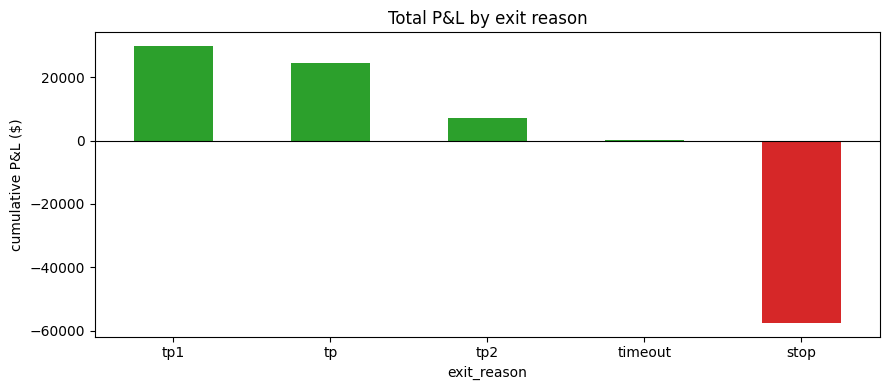

In [6]:
ax = exits.set_index('exit_reason')['total_pnl'].plot.bar(
    rot=0, color=['tab:green' if v > 0 else 'tab:red' for v in exits['total_pnl']])
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Total P&L by exit reason'); ax.set_ylabel('cumulative P&L ($)')
plt.tight_layout(); plt.show()

The asymmetry is the whole game: **stops** are the most frequent exit and drain the most capital, while the **take-profit legs** (`tp1`/`tp2`) are less frequent but carry the gains. The strategy only works if the average winner outweighs the volume of small losers — exactly what *profit factor* measures.

## 4. Per-symbol profitability
Is the edge broad, or carried by one or two instruments? (Concentration risk is a real finding — a strategy that only works on one ticker is fragile.)

In [7]:
by_symbol = q('''
  SELECT symbol, side, COUNT(*) AS trades,
         ROUND(100.0 * SUM(CASE WHEN pnl > 0 THEN 1 ELSE 0 END)/COUNT(*), 1) AS win_pct,
         ROUND(AVG(pnl_pct) * 100, 3) AS avg_return_pct,
         ROUND(SUM(pnl), 0)           AS total_pnl
  FROM trades
  GROUP BY symbol, side
  HAVING COUNT(*) >= 20
  ORDER BY total_pnl DESC
''')
by_symbol

,symbol,side,trades,win_pct,avg_return_pct,total_pnl
0,SOL/USDT,LONG,1256,62.600,1.247,"1,816.000"
1,NEAR/USDT,SHORT,1255,65.800,1.399,"1,708.000"
2,FET/USDT,LONG,1016,63.500,1.755,"1,250.000"
3,SOL/USDT,SHORT,1357,62.300,1.143,751.000
4,NEAR/USDT,LONG,1100,62.400,1.146,713.000
5,BTC/USDT,LONG,1437,60.200,0.384,99.000
6,FET/USDT,SHORT,1126,59.400,1.033,91.000
7,BTC/USDT,SHORT,1194,58.500,0.303,"-2,062.000"


## 5. Does holding longer help or hurt?
Bucket trades by how many bars they were held and look at the average return per bucket.

In [8]:
hold = q('''
  SELECT CASE
           WHEN hold_bars <  10 THEN '1. <10 bars'
           WHEN hold_bars <  30 THEN '2. 10-29'
           WHEN hold_bars <  60 THEN '3. 30-59'
           WHEN hold_bars < 120 THEN '4. 60-119'
           ELSE                      '5. 120+'
         END AS hold_bucket,
         COUNT(*) AS trades,
         ROUND(AVG(pnl_pct) * 100, 3) AS avg_return_pct
  FROM trades
  GROUP BY hold_bucket
  ORDER BY hold_bucket
''')
hold

,hold_bucket,trades,avg_return_pct
0,1. <10 bars,2923,1.552
1,2. 10-29,3356,0.712
2,3. 30-59,1762,0.778
3,4. 60-119,1103,1.068
4,5. 120+,597,0.869


## 6. The real test — does the edge survive out-of-sample?
A strategy tuned on historical data will always look good *in-sample*. The walk-forward windows re-optimize on a training window, then test on the next, unseen window. Comparing in-sample (IS) Sharpe to out-of-sample (OOS) Sharpe quantifies **overfitting**: the gap is the performance that doesn't generalize.

In [9]:
overfit = q('''
  SELECT COUNT(*) AS windows,
         ROUND(AVG(is_sharpe), 2)  AS avg_is_sharpe,
         ROUND(AVG(oos_sharpe), 2) AS avg_oos_sharpe,
         ROUND(AVG(is_sharpe) - AVG(oos_sharpe), 2) AS sharpe_degradation,
         ROUND(100.0 * SUM(CASE WHEN oos_sharpe > 0 THEN 1 ELSE 0 END)/COUNT(*), 1) AS pct_oos_positive
  FROM wf_windows
''')
overfit

,windows,avg_is_sharpe,avg_oos_sharpe,sharpe_degradation,pct_oos_positive
0,6,1.320,0.780,0.540,66.700


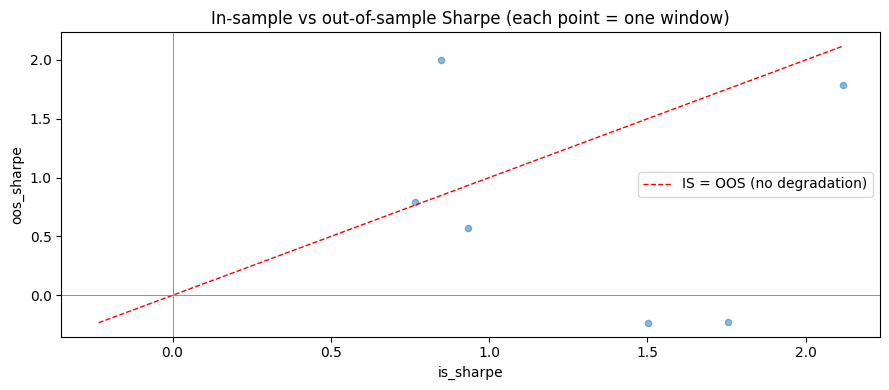

In [10]:
w = q('SELECT window_num, is_sharpe, oos_sharpe FROM wf_windows ORDER BY window_num')
ax = w.plot.scatter(x='is_sharpe', y='oos_sharpe', alpha=0.5)
lim = [min(w.is_sharpe.min(), w.oos_sharpe.min()), max(w.is_sharpe.max(), w.oos_sharpe.max())]
ax.plot(lim, lim, 'r--', lw=1, label='IS = OOS (no degradation)')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_title('In-sample vs out-of-sample Sharpe (each point = one window)')
ax.legend(); plt.tight_layout(); plt.show()

Points below the dashed line lost performance out-of-sample. The average IS→OOS drop is the headline overfitting number — and the share of windows that stay positive OOS tells you how often the tuned edge actually carried forward.

## 7. Equity curve & drawdown — drawdown computed in SQL
Rather than pull the full series into pandas and compute drawdown there, we use a **window function** — `MAX(equity) OVER (ORDER BY timestamp …)` gives the running peak, and `equity / peak − 1` is the drawdown — so the database does the heavy lifting.

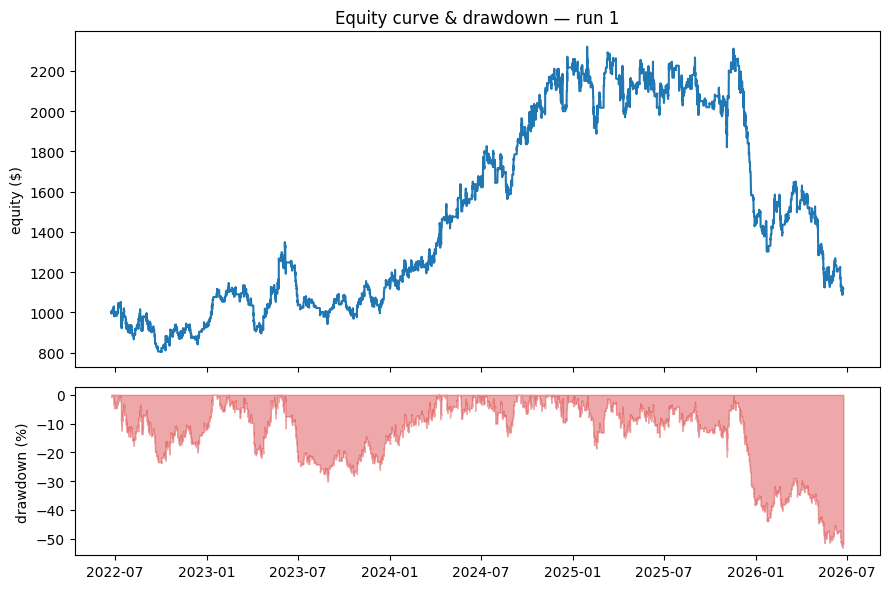

In [11]:
run_id = q('SELECT run_id FROM equity_points GROUP BY run_id ORDER BY COUNT(*) DESC LIMIT 1').iloc[0, 0]
curve = q(f'''
  WITH c AS (
    SELECT timestamp, equity,
           MAX(equity) OVER (ORDER BY timestamp ROWS UNBOUNDED PRECEDING) AS peak
    FROM equity_points WHERE run_id = {run_id}
  )
  SELECT timestamp, equity, 100.0 * (equity / peak - 1.0) AS drawdown_pct
  FROM c ORDER BY timestamp
''')
curve['timestamp'] = pd.to_datetime(curve['timestamp'])

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.plot(curve['timestamp'], curve['equity']); a1.set_ylabel('equity ($)')
a1.set_title(f'Equity curve & drawdown — run {run_id}')
a2.fill_between(curve['timestamp'], curve['drawdown_pct'], 0, color='tab:red', alpha=0.4)
a2.set_ylabel('drawdown (%)'); plt.tight_layout(); plt.show()

## Takeaways
- **One strategy carries the edge.** The scorecard separates a profitable, positive-Sharpe strategy from one that doesn't clear costs.
- **The P&L shape is stop-heavy.** Frequent small stops are paid for by fewer, larger take-profit exits — a low win rate can still be profitable if the payoff ratio holds.
- **Out-of-sample is where edges die.** The IS→OOS Sharpe gap quantifies overfitting and is the number to trust over any single in-sample backtest.

*All figures are read live from `backtester.db`; re-run after new backtests to refresh.*